# Can a neural network learn a simple filter?

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy
from scipy.fft import fft
import numpy as np
from tqdm import tqdm

## Signal Generation

In [ ]:
t = 1
fs = 1000
n = np.linspace(0, fs * t, fs * t + 1)

desired = np.sin(2 * np.pi * (93.75/fs) * n)

In [ ]:
def plot(x, title='Signal'):
    y = fft(x, 1001)
    freq = np.linspace(-np.pi, np.pi, len(y))

    fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=False)

    axs[0].plot(x)
    axs[0].set_xlabel('n')
    axs[0].set_ylabel('x[n]')
    axs[0].set_title(title)

    axs[1].plot(freq, np.fft.fftshift(np.abs(y)))
    axs[1].set_xlabel('Frequency (rad)')
    axs[1].set_ylabel('Magnitude')
    axs[1].set_title('Magnitude Response')

    axs[2].plot(freq, np.fft.fftshift(np.angle(y)))
    axs[2].set_xlabel('Frequency (rad)')
    axs[2].set_ylabel('Phase')
    axs[2].set_title('Phase Response')

    plt.tight_layout()
    plt.show()

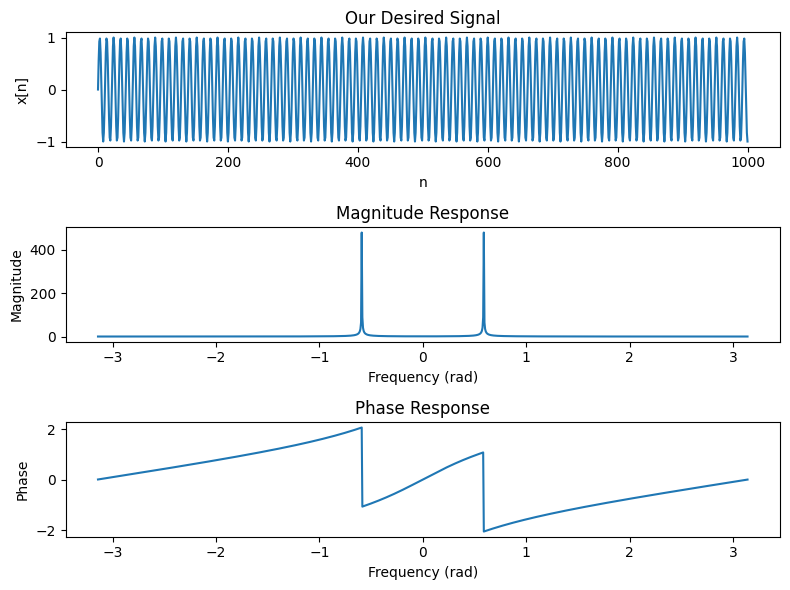

In [ ]:
plot(desired, 'Desired Signal')

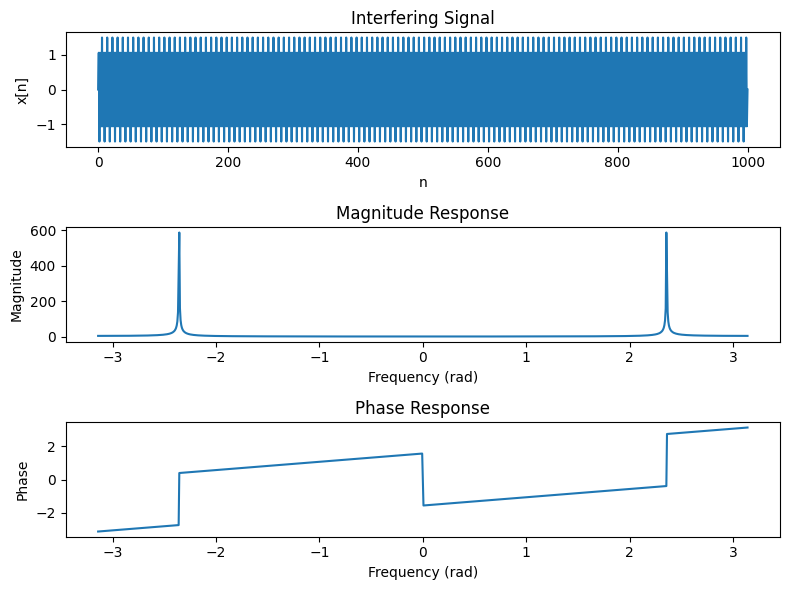

In [ ]:
interference = 1.5*np.sin(2 * np.pi * (4*93.75/fs) * n)
plot(interference, 'Interfering Signal')

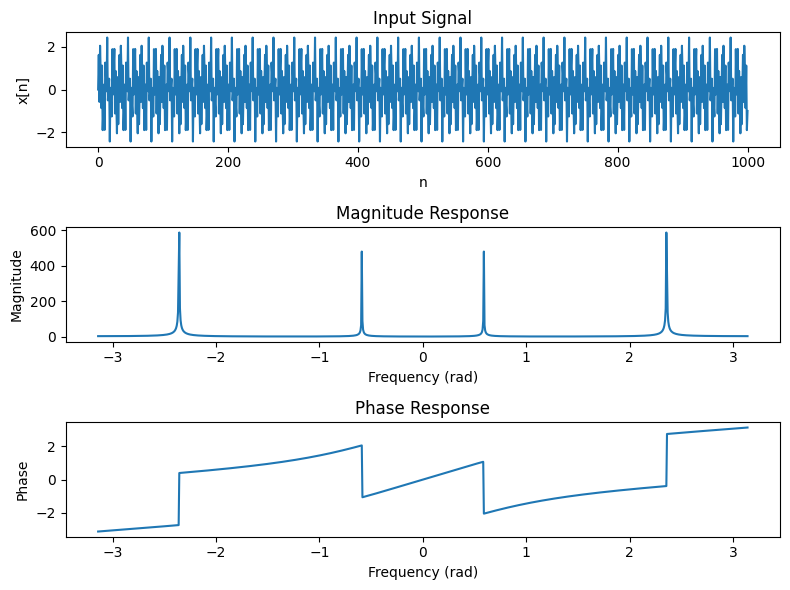

In [ ]:
input_signal = desired + interference
plot(input_signal, 'Input Signal')

## CNN

In [ ]:
class LPFConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.filter = nn.Conv1d(1, 1, 10, padding=1)
    def forward(self, x):
        return self.filter(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LPFConv().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

input_tensor = torch.tensor(input_signal, dtype=torch.float32)
input_tensor = input_tensor.view(1, 1, -1)

desired_tensor = torch.tensor(desired[0:994], dtype=torch.float32)
desired_tensor = desired_tensor.view(1, 1, -1)

In [ ]:
epochs = 50
losses = []
for _ in tqdm(range(epochs)):
    epoch_loss = 0
    for i in range(10):
        optimizer.zero_grad()
        output = model(input_tensor)
        loss = criterion(output, desired_tensor)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / 10)

100%|██████████| 50/50 [00:00<00:00, 109.63it/s]


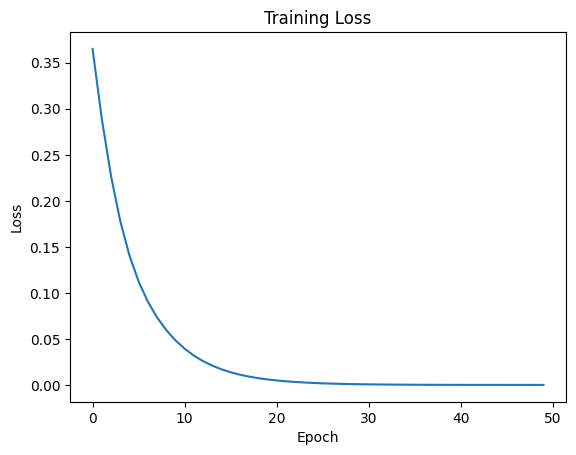

In [ ]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Below we see the last output of the model during training. We see in the magnitude response that the interfering frequency is pretty much removed.

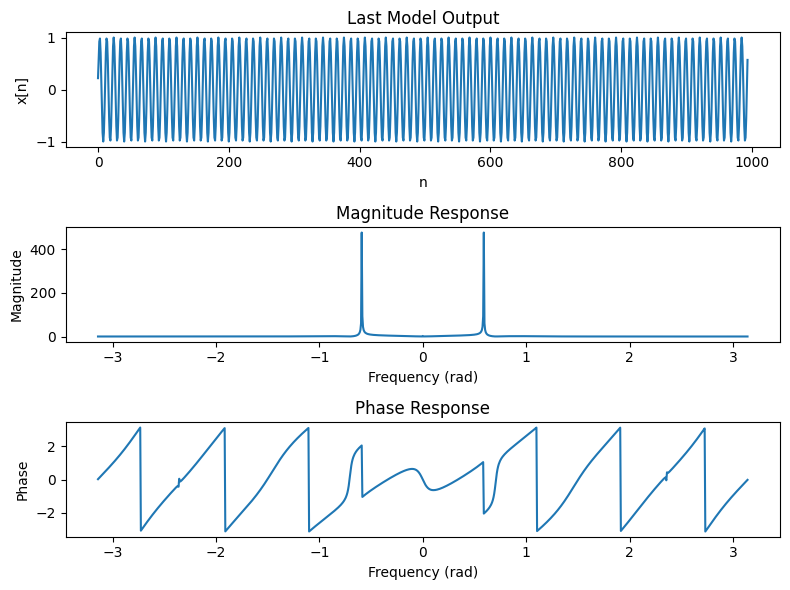

In [ ]:
plot(output.detach().numpy().flatten(), title='Last Model Output')

In [ ]:
conv_weights = model.filter.weight.data.cpu().numpy().squeeze()
print("Conv1d weights:", conv_weights)

Conv1d weights: [ 0.13533346  0.20649134 -0.1048369   0.04889374 -0.03723992 -0.08592118
 -0.43001968 -0.17887194 -0.16916841 -0.06000348]


we can view the magnitude spectrum of the weights of the convolutional layer below and see that it is 1 for the frequency we want to preserve and 0 for the interfering frequency we want to remove.

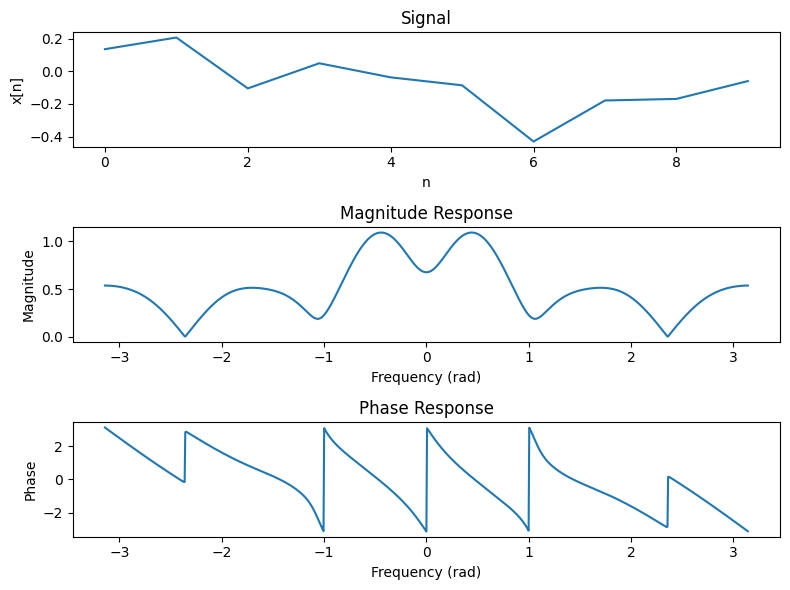

In [ ]:
plot(conv_weights)

## FFNN

Below we see a similar procedure using a feed-forward neural network with ReLU nonlinearities. Since the length of the input signal is quite large, there are many weights that allow the model to fit well for this specific use case.

In [ ]:
class LPFMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(1001, 8),
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.Linear(8, 1001)
        )

    def forward(self, x):
        x = self.mlp(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LPFMLP().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

input_tensor = torch.tensor(input_signal, dtype=torch.float32)
input_tensor = input_tensor.view(1, 1, -1)

desired_tensor = torch.tensor(desired, dtype=torch.float32)
desired_tensor = desired_tensor.view(1, 1, -1)

In [ ]:
epochs = 50
losses = []
for _ in tqdm(range(epochs)):
    epoch_loss = 0
    for i in range(10):
        optimizer.zero_grad()
        output = model(input_tensor)
        loss = criterion(output, desired_tensor)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / 10)

100%|██████████| 50/50 [00:00<00:00, 59.98it/s]


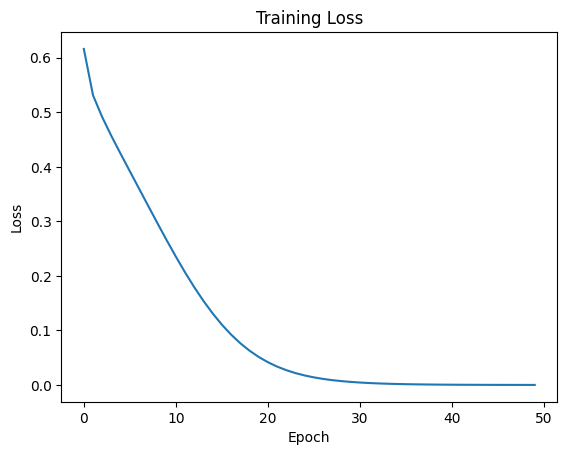

In [ ]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

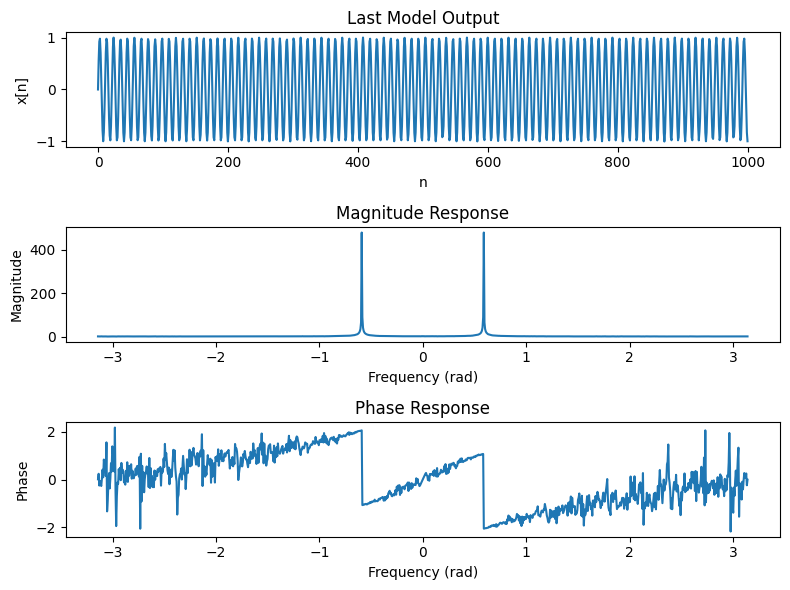

In [ ]:
plot(output.detach().numpy().flatten(), title='Last Model Output')

## TODOs:
- frequency sweep to get magnitude response of the FFNN system
- try with multiple high frequency interfering signals in order to approximate a general use low pass filter